<a href="https://colab.research.google.com/github/esraa9895/thesis-code/blob/main/regression_BFGS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install datasets

In [ ]:
# importing requuired libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
import datetime
import time

# functions

In [ ]:

def strong_wolfe(f, g, xk, alpha, pk, c2):
  # typically, c2 = 0.9 when using Newton or quasi-Newton's method.
  #            c2 = 0.1 when using non-linear conjugate gradient method.
  c1 = 1e-4
  return f(xk + alpha * pk) <= f(xk) + c1 * alpha * np.dot(pk.T,g(xk)) and abs(
      np.dot(pk.T,g(xk + alpha * pk))) <= c2 * abs(np.dot(pk.T,g(xk)))
# line-search step len
def step_length(f, g, xk, alpha, pk, c2):
  return interpolation(f, g,
                       lambda alpha: f(xk + alpha * pk),
                       lambda alpha: np.dot(pk.T,g(xk + alpha * pk)),
                       alpha, c2,
                       lambda f, g, alpha, c2: strong_wolfe(f, g, xk, alpha, pk, c2))


def interpolation(f, g, f_alpha, g_alpha, alpha, c2, strong_wolfe_alpha, iters=20):
  # referred implementation here:
  # https://github.com/tamland/non-linear-optimization
  l = 0.0
  h = 1.0
  for i in range(iters):
    if strong_wolfe_alpha(f, g, alpha, c2):
      return alpha

    half = (l + h) / 2
    alpha = - g_alpha(l) * (h**2) / (2 * (f_alpha(h) - f_alpha(l) - g_alpha(l) * h))
    if alpha < l or alpha > h:
      alpha = half
    if g_alpha(alpha) > 0:
      h = alpha
    elif g_alpha(alpha) <= 0:
      l = alpha
  return alpha

In [ ]:
def computeCost(theta):
    inner = np.power(((x_train.dot(theta)) - y_train), 2)
    return np.sum(inner) / (2 * len(x_train))

In [ ]:
def grad(theta):
    parameters = len(theta)
    g = []
    error = (x_train.dot(theta)) - y_train

    for i in range(parameters):
        term = np.dot(error.T, x_train[:, i])
        g.append(term/len(x_train))
    return g

Residuals for multi-dimensional Rosenbrock function
def rosenbrock_residuals(x):
    n = len(x)
    residuals = []
    for i in range(0, n - 1, 2):
        r1 = 10 * (x[i + 1] - x[i] ** 2)
        r2 = 1 - x[i]
        residuals.extend([r1, r2])
    return np.array(residuals)

 Jacobian of the residuals for multi-dimensional Rosenbrock
def jacobian_rosenbrock(x):
    n = len(x)
    m = n if n % 2 == 0 else n - 1  # handle odd-length x (ignore last term)
    J = np.zeros((m, n))

    row = 0
    for i in range(0, m, 2):
        # r1 = 10 * (x[i+1] - x[i]**2)
        J[row, i] = -20 * x[i]
        J[row, i + 1] = 10
        row += 1
        # r2 = 1 - x[i]
        J[row, i] = -1
        row += 1
    return J

In [ ]:
def hessian(theta):
    m, n = x_train.shape
    H = np.zeros((n, n))

    for i in range(n):  # row
        for j in range(n):  # column
            term = np.dot(x_train[:, i].T, x_train[:, j])
            H[i, j] = term / m
    return H

In [ ]:
def gradientDescent(X, y, theta, alpha, iters, tol):
    temp = np.zeros(theta.shape)
    parameters = len(theta)
    cost = []

    for i in range(iters):
        cost_old= computeCost(theta)
        gk = np.array(grad(theta))
       # if np.linalg.norm(gk) < err:
        #       break
        error = np.subtract(X.dot(theta), y)

        for j in range(parameters):
            term = np.dot(error.T, X[:, j])
            temp[j] = theta[j] - ((alpha / len(X)) * np.sum(term))

        cost_new= computeCost(temp)

        if np.linalg.norm(cost_new - cost_old) < tol:
            break
        #if np.linalg.norm(temp - theta) < 1e-5:
         #   xtheta = temp
          #  break

        theta = temp
        cost.append(computeCost(theta))

    return theta, cost, i

In [ ]:
def newton(f, g ,h, x0, iterations, error):
    """
    Newton's Method for unconstrained optimization applied to regression problems.

    This function implements the Newton optimization algorithm to iteratively
    minimize an objective (cost) function using first- and second-order
    derivative information (gradient and Hessian).

    Parameters
    ----------
    f : callable
        Objective (cost) function to be minimized. Takes a parameter vector x
        and returns a scalar value.

    g : callable
        Gradient of the objective function. Takes a parameter vector x and
        returns a gradient vector.

    h : callable
        Hessian matrix of the objective function. Takes a parameter vector x
        and returns a square matrix.

    x0 : ndarray
        Initial guess of the parameter vector.

    iterations : int
        Maximum number of iterations allowed.

    tol : float
        Convergence tolerance. The algorithm stops when the absolute change
        in the cost function between successive iterations is less than tol.

    Returns
    -------
    xk : ndarray
        Estimated optimal parameter vector after convergence.

    cost : list
        List containing the value of the objective function at each iteration.

    i : int
        Number of iterations performed before convergence or termination.

    Notes
    -----
    - Newton's method exhibits quadratic convergence near the optimum
      when the Hessian is positive definite.
    - The method may fail or become unstable if the Hessian is singular
      or ill-conditioned.
    - A line search strategy is used to ensure stable convergence.
    """
    xk = x0
    c2 = 0.9
    cost = []

    for i in range(iterations):
      # compute search direction
      gk =  np.array(g(xk))
      Hk =  np.array(h(xk))
      cost_old= f(xk)

      pk = -Hk.dot(gk)

      # obtain step length by line search
      alpha = step_length(f, g, xk, 1.0, pk, c2)
      # update x
      xk1 = xk + alpha * pk

      cost_new= f(xk1)
      error = cost_old -cost_new
      if  np.abs(error) < tol:
            break

     # print('np.linalg.norm(xk1 - xk) ', np.linalg.norm(xk1 - xk), 'and error is ' , error)

      # if np.linalg.norm(xk1 - xk) < error:
      #    xk = xk1
      #    break

      Hk= h(xk1)
      xk = xk1
      cost.append(f(xk))
    return xk, cost, i

In [ ]:
# Residuals for regression
def regression_residuals(theta, X, y):
    return y - X.dot(theta)

# Jacobian for regression
def jacobian_regression(X):
    return -X


def gauss_newton(X, y, theta0, iterations, tol=1e-6):
    """
    Gauss_newton algorithm for regression models in gradientDescent style.

    Parameters:
        X : ndarray
            Feature matrix (m x n).
        y : ndarray
            Target vector (m, ).
        theta0 : ndarray
            Initial parameter vector.
        iters : int
            Maximum number of iterations.
        tol : float
            Stopping tolerance based on cost change.

    Returns:
        theta : ndarray
            Final parameter estimates.
        i : int
            Number of iterations performed.
        cost : list
            Cost values per iteration.
    """
    theta = theta0.copy()
    cost = []

    for i in range(iters):
        # residuals
        r = regression_residuals(theta, X, y)
        # Jacobian
        J = jacobian_regression(X)

        # Normal equations: (JᵀJ) Δ = Jᵀ r
        JTJ = J.T @ J
        JTr = J.T @ r

        # Check invertibility
        if np.linalg.cond(JTJ) > 1e12:
            print("Matrix nearly singular at iteration", i)
            break

        # Solve for update
        delta = np.linalg.solve(JTJ, JTr)
        theta = theta + delta

        # Track cost (MSE)
        cost.append(np.mean(r**2))

        # Convergence check
        if np.linalg.norm(delta) < tol:
            break

    return theta, i, cost

In [ ]:
def levenberg_marquardt(X, y, theta, iters, tol, mu=1e-3):
    """
    Levenberg-Marquardt algorithm for regression models in gradientDescent style.

    Parameters:
        X : ndarray
            Feature matrix (m x n).
        y : ndarray
            Target vector (m, ).
        theta : ndarray
            Initial parameter vector.
        iters : int
            Maximum number of iterations.
        tol : float
            Stopping tolerance based on cost change.
        mu : float
            Initial damping parameter.

    Returns:
        theta : ndarray
            Final parameter estimates.
        cost : list
            Cost values per iteration.
        i : int
            Number of iterations performed.
    """
    m, n = X.shape
    cost = []

    for i in range(iters):
        # residuals and Jacobian
        residuals = y - X.dot(theta)         # r(θ)
        J = -X                               # Jacobian

        # cost function (MSE)
        cost_old = np.mean(residuals**2)

        # Compute LM step: (JᵀJ + μI) p = Jᵀr
        H = J.T @ J
        A = H + mu * np.eye(n)
        g = J.T @ residuals
        pk = np.linalg.solve(A, g)

        # Update theta
        theta_new = theta + pk

        # Compute new cost
        residuals_new = y - X.dot(theta_new)
        cost_new = np.mean(residuals_new**2)

        # Convergence check
        if np.abs(cost_old - cost_new) < tol:
            theta = theta_new
            cost.append(cost_new)
            break

        # Update damping parameter adaptively
        if cost_new < cost_old:
            theta = theta_new
            mu *= 0.7  # decrease damping
        else:
            mu *= 2.0  # increase damping

        cost.append(cost_new)

    return theta, i,cost


In [ ]:
def SR1(f, g, x0, iterations, error):
  xk = x0
  c2 = 0.9
  I = np.identity(xk.size)
  Hk = I
  cost=[]
  for i in range(iterations):
    # compute search direction
    gk =  np.array(g(xk))
    pk = -Hk.dot(gk)
    cost_old= f(xk)
    if np.linalg.norm(gk) < error:
        break

    # obtain step length by line search
    alpha = step_length(f, g, xk, 1.0, pk, c2)

    # update x
    xk1 = xk + alpha * pk
    gk1 =  np.array(g(xk1))
    cost_new= f(xk1)
    #if np.linalg.norm(cost_new - cost_old) < error:
    #    break

    # define sk and yk for convenience
    sk = xk1 - xk
    yk = gk1 - gk

    # Hs = Hk @ sk
    # if np.dot(yk - Hs, sk) > 1e-8:  # Ensure denominator is not too small
    #     Hk1 = Hk + np.outer((yk - Hs), (yk - Hs)) / np.dot((yk - Hs), sk)


    # compute H_{k+1} by SR1 update
    s_Hy = (sk-(Hk@ yk ))
    if(s_Hy.T.dot(yk)==0):
        print('divition by zero is not allowed')
        print("Did not converge.")
        break
    rho_k = float(1.0 / s_Hy.T.dot(yk))

        #rho_k = 1
    Hk1 = Hk+ rho_k* (s_Hy.T.dot(s_Hy))

    Hk = Hk1
    xk = xk1
    cost.append(f(xk))
  return xk, i ,cost

In [ ]:
def Ml_SR1(f, g, x0, iterations, error):
  xk = x0
  c2 = 0.9
  I = np.identity(xk.size)
  Hk = I
  cost=[]
  for i in range(iterations):
    # compute search direction
    gk =  np.array(g(xk))
    pk = -Hk.dot(gk)
    cost_old= f(xk)
    #if np.linalg.norm(gk) < error:
    #    break

    # obtain step length by line search
    alpha = step_length(f, g, xk, 1.0, pk, c2)

    # update x
    xk1 = xk + alpha * pk
    gk1 = np.array(g(xk1))
    cost_new= f(xk1)
    if np.linalg.norm(cost_new - cost_old) < error:
        break

    # define sk and yk for convenience
    sk = xk1 - xk
    yk = gk1 - gk

    # Hs = Hk @ sk
    # if np.dot(yk - Hs, sk) > 1e-8:  # Ensure denominator is not too small
    #     Hk1 = Hk + np.outer((yk - Hs), (yk - Hs)) / np.dot((yk - Hs), sk)


    # compute H_{k+1} by SR1 update
    s_Hy = (sk- yk)
    if(s_Hy.T.dot(yk)==0):
        print('divition by zero is not allowed')
        print("Did not converge.")
        break
    rho_k = float(1.0 / s_Hy.T.dot(yk))

        #rho_k = 1
    Hk1 = I+ rho_k* (s_Hy.T.dot(s_Hy))


    Hk = Hk1
    xk = xk1
    cost.append(f(xk))

  return xk, i, cost

In [ ]:
def bfgs(f, g, x0, iterations, tol):
    xk = x0
    c2 = 0.9
    I = np.identity(xk.size)
    Hk = I
    cost = []
    for i in range(iterations):
        cost_old= f(xk)
    # compute search direction
        gk =  np.array(g(xk))
        pk = -Hk.dot(gk)

       # if np.linalg.norm(gk) < tol:
        #      break
        # obtain step length by line search
        alpha = step_length(f, g, xk, 1.0, pk, c2)

        # update x
        xk1 = xk + alpha * pk
        gk1 = np.array(g(xk1))
        cost_new= f(xk1)
        error = cost_old -cost_new

        if  np.abs(error) < tol:
            break
        # define sk and yk for convenience
        sk = xk1 - xk
        yk = gk1 - gk

        # compute H_{k+1} by BFGS update
        rho_k = 1.0 / yk.T.dot(sk)
        Hk1 = (I - rho_k * np.outer(sk, yk)).dot(Hk).dot(I - \
                rho_k * np.outer(yk, sk)) + rho_k * np.outer(sk, sk)


        #if np.linalg.norm(xk1 - xk) < tol:
         #   xk = xk1
          #  break
        Hk = Hk1
        xk = xk1
        cost.append(f(xk))

    return xk, i,cost

In [ ]:
def scaled_bfgs(f, g, x0, iterations, error):
    xk = x0
    c2 = 0.9
    I = np.identity(xk.size)
    Hk = I
    cost = []

    for i in range(iterations):
    # compute search direction
        cost_old= f(xk)
        gk =  np.array(g(xk))
        pk = -Hk.dot(gk)

        #if np.linalg.norm(gk) < error:
         #     break

        # obtain step length by line search
        alpha = step_length(f, g, xk, 1.0, pk, c2)

        # update x
        xk1 = xk + alpha * pk
        gk1 = np.array(g(xk1))

        cost_new= f(xk1)
        if np.linalg.norm(cost_new - cost_old) < error:
            break

        # define sk and yk for convenience
        sk = xk1 - xk
        yk = gk1 - gk

        # compute H_{k+1} by BFGS update
        rho_k = (1.0 / yk.T.dot(sk))

        #Hk1 = (I - rho_k * np.outer(sk, yk)).dot(Hk).dot(I - \
        #       rho_k * np.outer(yk, sk)) + rho_k * np.outer(sk, sk)

        delta = (rho_k*6* (f(xk)-f(xk1)+sk.T.dot(gk1)))-2   #BFGSB
        #delta = (rho_k*2* (f(xk)-f(xk1)+sk.T.dot(gk1)))     #BFGSY
        #delta = ( yk.T.dot(sk))/ (yk.T.dot(yk)) #rho_k*(yk.T.dot(yk)) ##BFGSC

        '''
        #BFGSN
        Beta=np.exp(-1/np.power(i,2))
        delta = (yk.T.dot(sk))/ ((yk.T.dot(yk))+Beta)

        if alpha <np.exp(-1/np.power(i,2)):
            alpha = np.exp(-1/np.power(i,2))
            delta = 1


        maqam = sk.T.dot(Hk).dot(sk)+yk.T.dot(sk)
        alpha = yk.T.dot(sk)/maqam
        if alpha <np.exp(-1/np.power(i,2)):
            alpha = np.exp(-1/np.power(i,2))
            delta = 1
        '''

        Hk1 = Hk -rho_k*( (np.inner(np.outer(sk,yk), Hk) )+ np.outer(np.inner(Hk,yk.T) , sk) )+\
                ((1.0/delta)+rho_k*(yk.T.dot(Hk).dot(yk)))*(rho_k* np.outer(sk,sk))


        '''
        Hk1 = (I - rho_k * np.outer(sk, yk)).dot(Hk).dot(I - \
                rho_k * np.outer(yk, sk)) + rho_k * np.outer(sk, sk)
        '''
        # if np.linalg.norm(xk1 - xk) < error:
        #   xk = xk1
        #   break
        Hk = Hk1
        xk = xk1
        cost.append(f(xk))
    return xk, i,cost


In [ ]:
def double_scaled_bfgs(f, g, x0, iterations, error):
    xk = x0
    c2 = 0.9
    I = np.identity(xk.size)
    Hk = I
    X,Y = [],[]
    cost = []
    for i in range(iterations):
    # compute search direction
        gk =  np.array(g(xk))
        pk = -Hk.dot(gk)
        cost_old= f(xk)

        #if np.linalg.norm(gk) < error:
        #      break

        # obtain step length by line search
        alpha = step_length(f, g, xk, 1.0, pk, c2)

        # update x
        xk1 = xk + alpha * pk
        gk1 =  np.array(g(xk1))

        cost_new= f(xk1)
        if np.linalg.norm(cost_new - cost_old) < error:
            break

        # define sk and yk for convenience
        sk = xk1 - xk
        yk = gk1 - gk

        # compute H_{k+1} by BFGS update
        rho_k = (1.0 / yk.T.dot(sk))

        #Hk1 = (I - rho_k * np.outer(sk, yk)).dot(Hk).dot(I - \
         #       rho_k * np.outer(yk, sk)) + rho_k * np.outer(sk, sk)

        delta = (yk.T.dot(sk))/ ((yk.T.dot(yk))+(sk.T.dot(gk1)))
        alpha =(2-(delta*(yk.T.dot(yk)/yk.T.dot(sk))))/1

        delta = 1.0/delta
        alpha = 1.0/alpha

        Hk1 = alpha*I - alpha* (rho_k*( np.outer(sk,yk)+ np.outer(yk,sk)))+\
                    (delta+ alpha*(rho_k*(yk.T.dot(yk))))*(rho_k* np.outer(sk,sk))

        '''
        Hk1 = (I - rho_k * np.outer(sk, yk)).dot(Hk).dot(I - \
                rho_k * np.outer(yk, sk)) + rho_k * np.outer(sk, sk)
        '''
        # if np.linalg.norm(xk1 - xk) < error:
        #   xk = xk1
        #   break

        Hk = Hk1
        xk = xk1
        cost.append(f(xk))
    return xk, i + 1, cost


In [ ]:
def memory_less_bfgs(f, g, x0, iterations, error):
    xk = x0
    c2 = 0.9
    I = np.identity(xk.size)
    Hk = I
    X=[]
    Y=[]
    cost=[]
    for i in range(iterations):
    # compute search direction
        cost_old= f(xk)
        gk = np.array(g(xk))
        #if np.linalg.norm(gk) < error:
         #     break

        pk = -Hk.dot(gk)

        # obtain step length by line search
        alpha = step_length(f, g, xk, 1.0, pk, c2)

        # update x
        xk1 = xk + alpha * pk
        gk1 = np.array(g(xk1))
        X.append(xk[0]), Y.append(xk[1])

        cost_new= f(xk1)
        if np.linalg.norm(cost_new - cost_old) < error:
            break
        # define sk and yk for convenience
        sk = xk1 - xk
        yk = gk1 - gk

        # compute H_{k+1} by BFGS update
        rho_k = 1.0 / yk.T.dot(sk)
        Hk1 = (I - rho_k * np.outer(sk, yk)).dot(I - \
                rho_k * np.outer(yk, sk)) + rho_k * np.outer(sk, sk)

       # if np.linalg.norm(xk1 - xk) < error:
        #    xk = xk1
         #   break

        Hk = Hk1
        xk = xk1
        cost.append(f(xk))
    return xk, i ,cost

In [ ]:
def l_bfgs(f, g, x0, iterations, error, m=10):
  xk = x0
  c2 = 0.9
  I = np.identity(xk.size)
  sks = []
  yks = []
  X=[]
  Y=[]
  cost =[]
  def Hp(H0):
    m_t = len(sks)
    q = g(xk)
    a = np.zeros(m_t)
    b = np.zeros(m_t)
    for i in reversed(range(m_t)):
      s = sks[i]
      y = yks[i]
      rho_i = float(1.0 / y.T.dot(s))
      a[i] = rho_i * s.T.dot(q)
      q = q - a[i] * y

    r = H0.dot(q)

    for i in range(m_t):
      s = sks[i]
      y = yks[i]
      rho_i = float(1.0 / y.T.dot(s))
      b[i] = rho_i * y.T.dot(r)
      r = r + s * (a[i] - b[i])

    return r

  for i in range(iterations):
    # compute search direction
    cost_old = f(xk)
    gk = np.array(g(xk))
    pk = -Hp(I)

    if np.linalg.norm(gk) < error:
         break
    # obtain step length by line search
    alpha = step_length(f, g, xk, 1.0, pk, c2)

    # update x
    xk1 = xk + alpha * pk
    gk1 = np.array(g(xk1))

    cost_new= f(xk1)
    if np.linalg.norm(cost_new - cost_old) < error:
         break
    # define sk and yk for convenience
    sk = xk1 - xk
    yk = gk1 - gk

    sks.append(sk)
    yks.append(yk)
    if len(sks) > m:
      sks = sks[1:]
      yks = yks[1:]

    X.append(xk[0]), Y.append(xk[1])

    #if np.linalg.norm(xk1 - xk) < error:
     #   xk = xk1
      #  break

    xk = xk1
    cost.append(f(xk))
  return xk, i ,cost

In [ ]:
def accuracy(Y, f):
    r = np.power((Y - f), 2)
    RSS = np.sum(r)/(2*len(Y))

    t = np.power((Y - Y.mean()), 2)
    TSS = np.sum(t)/(2*len(Y))

    acc = 1 - (RSS / TSS)
    return acc

In [ ]:
def draw(n_iter, cost,name):
    # draw error graph
    fig, ax = plt.subplots(figsize=(5, 5))
    plt.scatter(np.arange(n_iter), cost, marker='o')
    ax.plot(np.arange(n_iter), cost, 'r')
    ax.set_xlabel('Iterations')
    ax.set_ylabel('Cost')
    ax.set_title('Error vs. Training Epoch\n by {} method'.format(name))

# read Data

## Apple Stock Price

In [ ]:
df = pd.read_csv("hf://datasets/Ammok/apple_stock_price_from_1980-2021/AAPL.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
df.head(5)

,Employee_ID,Age,Years_Experience,WFH_Days_Per_Week,Gender,Education_Level,Marital_Status,Has_Children,Location_Type,Department,...,Quality_Score,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Survey_Date,Response_Quality
0,EMP0001,39,10,2,Female,Associate Degree,Married,Yes,Urban,Product,...,58.1,52.1,72.1,4,48,55.9,6,8,2024-04-05,Medium
1,EMP0002,33,4,5,Female,Master Degree,Married,No,Urban,Customer Success,...,93.3,77.9,89.5,12,0,96.1,3,8,2024-01-29,High
2,EMP0003,40,3,3,Male,PhD,Single,Yes,Rural,Operations,...,84.7,63.2,95.0,15,24,90.4,5,6,2024-01-18,High
3,EMP0004,48,14,3,Male,Bachelor Degree,Married,Yes,Urban,Finance,...,67.8,82.5,95.0,8,8,100.0,10,5,2024-04-18,High
4,EMP0005,32,6,5,Male,High School,Divorced,Yes,Rural,Engineering,...,86.4,67.5,95.0,10,0,100.0,3,4,2024-02-19,High


In [ ]:
df.info()

In [ ]:
df.describe()

,Age,Years_Experience,WFH_Days_Per_Week,Work_Hours_Per_Week,Productivity_Score,Task_Completion_Rate,Quality_Score,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.190667,4.594667,2.857333,41.734000,83.094867,82.507133,84.410933,72.821667,90.488533,8.080000,25.465333,95.364400,5.678667,6.221333
std,8.406908,4.740607,1.489897,6.038285,15.227276,15.390392,13.881407,14.994149,9.051719,2.944947,19.056799,9.853226,2.052532,2.088201
min,22.000000,0.000000,0.000000,25.000000,35.000000,40.000000,50.000000,30.000000,43.400000,1.000000,0.000000,35.200000,1.000000,1.000000
25%,29.000000,1.000000,2.000000,37.000000,73.700000,72.200000,75.200000,62.600000,90.475000,6.000000,10.000000,97.250000,4.000000,5.000000
50%,35.000000,3.000000,3.000000,42.000000,86.700000,86.000000,87.600000,74.800000,95.000000,8.000000,25.000000,100.000000,6.000000,6.000000
75%,41.000000,7.000000,4.000000,46.000000,98.000000,96.100000,96.225000,84.200000,95.000000,10.000000,38.000000,100.000000,7.000000,8.000000
max,65.000000,32.000000,5.000000,65.000000,98.000000,100.000000,100.000000,95.000000,95.000000,19.000000,104.000000,100.000000,10.000000,10.000000


In [ ]:
# Convert Survey_Date to datetime
X['Date'] = pd.to_datetime(X['Date'], errors='coerce')

# Extract date features
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X['DayOfWeek'] = X['Date'].dt.dayofweek

# Drop original date column
X = X.drop(columns=['Date'])
X.head()

,Open,High,Low,Adj Close,Volume,Year,Month,DayOfWeek
0,0.128348,0.128906,0.128348,0.100178,469033600,1980,12,4
1,0.122210,0.122210,0.121652,0.094952,175884800,1980,12,0
2,0.113281,0.113281,0.112723,0.087983,105728000,1980,12,1
3,0.115513,0.116071,0.115513,0.090160,86441600,1980,12,2
4,0.118862,0.119420,0.118862,0.092774,73449600,1980,12,3


In [ ]:
#splitting into training and test

X , Y =df.drop(columns=['Close'], axis = 1), df['Close']

print('x data is ',X.shape)
print('y data is ',Y.shape)

x data is  (10468, 6)
y data is  (10468,)


## Remote Worker Productivity

In [ ]:
df = pd.read_csv("hf://datasets/nprak26/remote-worker-productivity/remote_work_productivity.csv")

In [ ]:
df.head()

,Employee_ID,Age,Years_Experience,WFH_Days_Per_Week,Gender,Education_Level,Marital_Status,Has_Children,Location_Type,Department,...,Quality_Score,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Survey_Date,Response_Quality
0,EMP0001,39,10,2,Female,Associate Degree,Married,Yes,Urban,Product,...,58.1,52.1,72.1,4,48,55.9,6,8,2024-04-05,Medium
1,EMP0002,33,4,5,Female,Master Degree,Married,No,Urban,Customer Success,...,93.3,77.9,89.5,12,0,96.1,3,8,2024-01-29,High
2,EMP0003,40,3,3,Male,PhD,Single,Yes,Rural,Operations,...,84.7,63.2,95.0,15,24,90.4,5,6,2024-01-18,High
3,EMP0004,48,14,3,Male,Bachelor Degree,Married,Yes,Urban,Finance,...,67.8,82.5,95.0,8,8,100.0,10,5,2024-04-18,High
4,EMP0005,32,6,5,Male,High School,Divorced,Yes,Rural,Engineering,...,86.4,67.5,95.0,10,0,100.0,3,4,2024-02-19,High


In [ ]:
df.describe()

,Age,Years_Experience,WFH_Days_Per_Week,Work_Hours_Per_Week,Productivity_Score,Task_Completion_Rate,Quality_Score,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.190667,4.594667,2.857333,41.734000,83.094867,82.507133,84.410933,72.821667,90.488533,8.080000,25.465333,95.364400,5.678667,6.221333
std,8.406908,4.740607,1.489897,6.038285,15.227276,15.390392,13.881407,14.994149,9.051719,2.944947,19.056799,9.853226,2.052532,2.088201
min,22.000000,0.000000,0.000000,25.000000,35.000000,40.000000,50.000000,30.000000,43.400000,1.000000,0.000000,35.200000,1.000000,1.000000
25%,29.000000,1.000000,2.000000,37.000000,73.700000,72.200000,75.200000,62.600000,90.475000,6.000000,10.000000,97.250000,4.000000,5.000000
50%,35.000000,3.000000,3.000000,42.000000,86.700000,86.000000,87.600000,74.800000,95.000000,8.000000,25.000000,100.000000,6.000000,6.000000
75%,41.000000,7.000000,4.000000,46.000000,98.000000,96.100000,96.225000,84.200000,95.000000,10.000000,38.000000,100.000000,7.000000,8.000000
max,65.000000,32.000000,5.000000,65.000000,98.000000,100.000000,100.000000,95.000000,95.000000,19.000000,104.000000,100.000000,10.000000,10.000000


In [ ]:
inf_cols = ['new_cardf_card_id_cnt_divide_installments_nunique', 'hist_last2_card_id_cnt_divide_installments_nunique']
train[inf_cols] = train[inf_cols].replace(np.inf, train[inf_cols].replace(np.inf, -99).max().max())
#test[inf_cols] = test[inf_cols].replace(np.inf, test[inf_cols].replace(np.inf, -99).max().max())


print('train:',train.shape)
#print('test:', test.shape)

In [ ]:
#splitting into training and test

X , Y =df.drop(columns=['Productivity_Score', "Employee_ID"], axis = 1), df['Productivity_Score']

print('x data is ',X.shape)
print('y data is ',Y.shape)

x data is  (1500, 28)
y data is  (1500,)


In [ ]:
X.head()

,Age,Years_Experience,WFH_Days_Per_Week,Gender,Education_Level,Marital_Status,Has_Children,Location_Type,Department,Job_Level,...,Quality_Score,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Survey_Date,Response_Quality
0,39,10,2,Female,Associate Degree,Married,Yes,Urban,Product,Mid-Level,...,58.1,52.1,72.1,4,48,55.9,6,8,2024-04-05,Medium
1,33,4,5,Female,Master Degree,Married,No,Urban,Customer Success,Senior,...,93.3,77.9,89.5,12,0,96.1,3,8,2024-01-29,High
2,40,3,3,Male,PhD,Single,Yes,Rural,Operations,Mid-Level,...,84.7,63.2,95.0,15,24,90.4,5,6,2024-01-18,High
3,48,14,3,Male,Bachelor Degree,Married,Yes,Urban,Finance,Manager,...,67.8,82.5,95.0,8,8,100.0,10,5,2024-04-18,High
4,32,6,5,Male,High School,Divorced,Yes,Rural,Engineering,Senior,...,86.4,67.5,95.0,10,0,100.0,3,4,2024-02-19,High


In [ ]:
test.head()

# missing data

In [ ]:
X.isna().sum()

,0
Age,0
Years_Experience,0
WFH_Days_Per_Week,0
Gender,0
Education_Level,0
Marital_Status,0
Has_Children,0
Location_Type,0
Department,0
Job_Level,0


In [ ]:
# drop null columns
n=0
for col in X.columns:
  if X[col].isnull().median()*100>40:
    print(n,col,':',X[col].isnull().sum())
    print('the diffrence is ',len(X[col]) - X[col].isnull().sum())
    print('the mean > 40, mean: ',X[col].isnull().mean()*100)
    X.drop(col, axis= 1, inplace= True)
  n+=1

557 new_cardf_card_id_part_cnt : 201917
the diffrence is  0
the mean > 40, mean:  100.0
558 new_cardf_card_id_part_purchase_amount_sum : 201917
the diffrence is  0
the mean > 40, mean:  100.0
559 new_cardf_card_id_part_purchase_amount_mean : 201917
the diffrence is  0
the mean > 40, mean:  100.0
560 new_cardf_card_id_part_purchase_amount_sum_percent : 201917
the diffrence is  0
the mean > 40, mean:  100.0


In [ ]:
unll_col = [col for col in X.columns if X[col].isna().sum() > 0]
print(unll_col)
print(len(unll_col))
#fill null values
for col in unll_col:
   X= X.fillna(X[col].median())

print(X.shape)

X.head()

['auth_installments_std', 'auth_price_std', 'auth_duration_skew', 'auth_amount_month_ratio_skew', 'hist_category_1_mean', 'hist_category_2_mean', 'hist_category_3_mean', 'hist_installments_mean', 'hist_installments_max', 'hist_installments_min', 'hist_installments_std', 'hist_month_lag_nunique', 'hist_month_lag_mean', 'hist_month_lag_max', 'hist_month_lag_min', 'hist_month_lag_std', 'hist_month_nunique', 'hist_month_mean', 'hist_month_max', 'hist_month_min', 'hist_month_std', 'hist_hour_nunique', 'hist_hour_mean', 'hist_hour_max', 'hist_hour_min', 'hist_hour_std', 'hist_weekofyear_nunique', 'hist_weekofyear_mean', 'hist_weekofyear_max', 'hist_weekofyear_min', 'hist_weekofyear_std', 'hist_dayofweek_nunique', 'hist_dayofweek_mean', 'hist_weekend_mean', 'hist_year_nunique', 'hist_card_id_size', 'hist_card_id_count', 'hist_purchase_date_max', 'hist_purchase_date_min', 'hist_price_mean', 'hist_price_max', 'hist_price_min', 'hist_price_std', 'hist_duration_mean', 'hist_duration_min', 'hist_d

,feature_1,feature_2,feature_3,year,elapsed_time,weekofyear,dayofyear,month,auth_category_1_mean,auth_category_2_mean,...,card_id_cnt_ratio,purchase_amount_total,purchase_amount_ratio,month_diff_ratio,installments_total,installments_ratio,price_total,new_CLV,hist_CLV,CLV_ratio
0,5,2,1,2017,273,22,152,6,0.000000,1.048583,...,1.769231,21403.0,0.139306,0.998356,270.0,0.093117,79.270370,755.260740,3059.343908,0.246870
1,4,1,0,2017,424,52,1,1,0.085546,1.000000,...,0.545455,34299.0,0.002455,0.999635,509.0,0.011928,67.385070,6.235051,4654.362063,0.001340
2,2,2,0,2016,577,31,214,8,0.000000,4.609756,...,0.500000,1996.0,0.015776,0.989225,42.0,0.024390,47.523810,0.392405,49.210832,0.007974
3,4,3,0,2017,181,35,244,9,0.155844,3.064935,...,0.000000,5724.0,0.071709,1.002767,92.0,0.069767,62.217392,33.512500,0.000000,0.000000
4,1,3,0,2017,120,44,305,11,0.093750,3.492188,...,7.200000,38344.0,0.137467,1.000927,180.0,0.250000,213.022220,2089.653378,2113.230556,0.988843


In [ ]:
print('the sum of duplicated values ',X.duplicated().sum())

the sum of duplicated values  0


# encoded categorical data  (Remote Worker Productivity )

In [ ]:
X.head()

,Age,Years_Experience,WFH_Days_Per_Week,Gender,Education_Level,Marital_Status,Has_Children,Location_Type,Department,Job_Level,...,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Response_Quality,Survey_Year,Survey_Month,Survey_DayOfWeek
0,39,10,2,Female,Associate Degree,Married,Yes,Urban,Product,Mid-Level,...,72.1,4,48,55.9,6,8,Medium,2024,4,4
1,33,4,5,Female,Master Degree,Married,No,Urban,Customer Success,Senior,...,89.5,12,0,96.1,3,8,High,2024,1,0
2,40,3,3,Male,PhD,Single,Yes,Rural,Operations,Mid-Level,...,95.0,15,24,90.4,5,6,High,2024,1,3
3,48,14,3,Male,Bachelor Degree,Married,Yes,Urban,Finance,Manager,...,95.0,8,8,100.0,10,5,High,2024,4,3
4,32,6,5,Male,High School,Divorced,Yes,Rural,Engineering,Senior,...,95.0,10,0,100.0,3,4,High,2024,2,0


In [ ]:
#get uniqe value
n=1
for i in X.columns:
  if X[i].dtypes== 'object':
    print("***************")
    print(n,'colums name : ',i)
    uniqe_array =  X[i].unique()
    print(uniqe_array)
    print(f"the length is {len(X[i].unique())}")
    n+=1

***************
1 colums name :  Gender
['Female' 'Male' 'Non-binary']
the length is 3
***************
2 colums name :  Education_Level
['Associate Degree' 'Master Degree' 'PhD' 'Bachelor Degree' 'High School'
 'Professional Degree']
the length is 6
***************
3 colums name :  Marital_Status
['Married' 'Single' 'Divorced' 'In Relationship']
the length is 4
***************
4 colums name :  Has_Children
['Yes' 'No']
the length is 2
***************
5 colums name :  Location_Type
['Urban' 'Rural' 'Suburban']
the length is 3
***************
6 colums name :  Department
['Product' 'Customer Success' 'Operations' 'Finance' 'Engineering' 'HR'
 'Marketing' 'Sales' 'Data Science' 'Design']
the length is 10
***************
7 colums name :  Job_Level
['Mid-Level' 'Senior' 'Manager' 'Junior' 'Lead' 'Director']
the length is 6
***************
8 colums name :  Company_Size
['Large (1001-5000)' 'Startup (1-50)' 'Medium (201-1000)' 'Small (51-200)'
 'Enterprise (5000+)']
the length is 5
***********

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Example dataset (replace with your actual df)
# df = pd.read_csv("your_data.csv")

# Define quality-related features (ordinal)
quality_features = [
    "Response_Quality",
    "Home_Office_Quality",
    "Internet_Speed_Category",
    "Manager_Support_Level",
    "Company_Size",
    "Education_Level",
    "Job_Level"
]

# Separate columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
other_features = [col for col in categorical_features if col not in quality_features]
print('categorical_features',categorical_features, len(categorical_features))
print("Quality features:", quality_features, len(other_features))
print("Other categorical features:", other_features, len(other_features))


categorical_features ['Gender', 'Education_Level', 'Marital_Status', 'Has_Children', 'Location_Type', 'Department', 'Job_Level', 'Company_Size', 'Industry', 'Home_Office_Quality', 'Internet_Speed_Category', 'Manager_Support_Level', 'Team_Collaboration_Frequency', 'Survey_Date', 'Response_Quality'] 15
Quality features: ['Response_Quality', 'Home_Office_Quality', 'Internet_Speed_Category', 'Manager_Support_Level', 'Company_Size', 'Education_Level', 'Job_Level'] 8
Other categorical features: ['Gender', 'Marital_Status', 'Has_Children', 'Location_Type', 'Department', 'Industry', 'Team_Collaboration_Frequency', 'Survey_Date'] 8


In [ ]:

# Apply Label Encoding for quality features
label_encoders = {}
for col in quality_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [ ]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoders = {}
# Apply Label Encoding for quality features
for col in other_features:
    one_hot_encoder = OneHotEncoder(sparse_output=False, drop=None)  # drop=None keeps all categories
    encoded = one_hot_encoder.fit_transform(X[col].to_numpy().reshape(-1,1))

    # Convert back to DataFrame with new column names
    encoded_df = pd.DataFrame(encoded,
                              columns=[f"{col}_{cat}" for cat in one_hot_encoder.categories_[0]],
                              index=X.index)

    # Drop original column and concat encoded version
    X = pd.concat([X.drop(columns=[col]), encoded_df], axis=1)

    one_hot_encoders[col] = one_hot_encoder


In [ ]:

X.head()

,Age,Years_Experience,WFH_Days_Per_Week,Education_Level,Job_Level,Company_Size,Home_Office_Quality,Internet_Speed_Category,Work_Hours_Per_Week,Manager_Support_Level,...,Survey_Date_2024-05-06,Survey_Date_2024-05-07,Survey_Date_2024-05-08,Survey_Date_2024-05-09,Survey_Date_2024-05-10,Survey_Date_2024-05-11,Survey_Date_2024-05-12,Survey_Date_2024-05-13,Survey_Date_2024-05-14,Survey_Date_2024-05-15
0,39,10,2,0,4,1,2,3,41,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,33,4,5,3,5,4,2,3,52,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,3,3,4,4,2,1,0,43,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,48,14,3,1,3,2,1,3,45,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,32,6,5,2,5,3,0,1,42,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#  split data and make scalling

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

print("Training Data",X_train.shape)
print("Testing Data",y_train.shape)


Training Data (1050, 179)
Testing Data (1050,)


In [ ]:
X_test.shape, y_test.shape

((450, 179), (450,))

In [ ]:
X_train.head()

,Open,High,Low,Adj Close,Volume,Year,Month,DayOfWeek
4560,0.348214,0.367188,0.348214,0.312043,725312000,1998,12,0
10067,119.440002,119.669998,117.870003,118.204796,81581900,2020,11,4
1947,0.359375,0.361607,0.350446,0.282672,127680000,1988,8,3
2318,0.303571,0.312500,0.301339,0.246079,102166400,1990,2,1
2299,0.310268,0.310268,0.294643,0.237163,197299200,1990,1,2


In [ ]:
print("Training Data",X_test.shape)
print("Testing Data",y_test.shape)

Training Data (450, 179)
Testing Data (450,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
x_train= scaler.transform(X_train)
x_test= scaler.transform(X_test)
X_train = pd.DataFrame(x_train)
X_test = pd.DataFrame(x_test)

In [ ]:
#generate model
model = LinearRegression()
model.fit(X_train, y_train)
#print(X_train.shape)
y_train_pred = model.predict(X_train)

#predict result
y_test_pred = model.predict(X_test)

mse = mean_squared_error( y_test, y_test_pred)
print(f"Mean Squared Error: {mse}")

rmse = root_mean_squared_error( y_test, y_test_pred)
print(f"root Mean Squared Error: {rmse}")

#compute accuracy
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f'training r2: {r2_train}, test r2: {r2_test}')


Mean Squared Error: 17.100953930693798
root Mean Squared Error: 4.135329966362273
training r2: 0.9393854417267521, test r2: 0.9158470421836997


In [ ]:
from sklearn.linear_model import SGDRegressor

#  Gradient Descent regession
gd_model = SGDRegressor(max_iter=1000, tol=1e-5, random_state=42)

gd_model.fit(X_train, y_train)

# التنبؤ
y_pred_gd = gd_model.predict(X_test)

# حساب الخطأ
mse_gd = mean_squared_error(y_test, y_pred_gd)
print("Gradient Descent MSE:", mse_gd)
print("Gradient Descent r2_score:", r2_score(y_test, y_pred_gd))


Gradient Descent MSE: 0.09459940781351968
Gradient Descent r2_score: 0.9998955350578729


In [ ]:
x_train = pd.DataFrame(X_train)
x_test = pd.DataFrame(X_test)

y_train = pd.DataFrame(y_train)
y_test = pd.DataFrame(y_test)

In [ ]:
test = pd.DataFrame(test)

In [ ]:
x_train.insert(0, 'Ones', 1)
  # convert to arrayes and initialize theta
cols = x_train.shape[1]
x_train = np.array(x_train.values)

y_train = np.array(y_train.values)
dimention= y_train.shape[0]
y_train = y_train.reshape(dimention,1)
theta = np.zeros(cols)
theta = theta.reshape(cols, 1)
print('x train shape is ',x_train.shape)
print('y train shape is ',y_train.shape)
print('theta shape is ',theta.shape)


x train shape is  (1050, 180)
y train shape is  (1050, 1)
theta shape is  (180, 1)


In [ ]:
x_test.insert(0, 'Ones', 1)
  # convert to arrayes
x_test = np.array(x_test.values)

y_test = np.array(y_test.values)
dimention= y_test.shape[0]
y_test = y_test.reshape(dimention,1)

print('x train shape is ',x_test.shape)
print('y train shape is ',y_test.shape)


x train shape is  (450, 180)
y train shape is  (450, 1)


In [ ]:
test.insert(0, 'Ones', 1)
  # convert to arrayes
test = np.array(test.values)


print('test shape is ',test.shape)

NameError: name 'test' is not defined

# Regression models

In [ ]:
# initialize number of iterations
iters = 1000
tol= 1e-5

*******************gradientDescent*******************
  gradientDescent terminated in 219 theta = ,  accuracy= 0.9393827913726865
Execution time: 0:00:00.954137


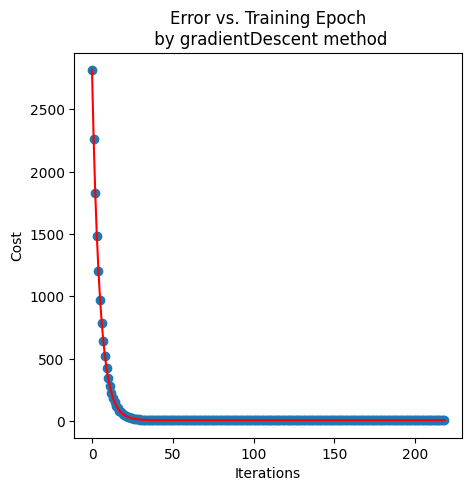

In [ ]:
print('*******************gradientDescent*******************')

start = datetime.datetime.now()
g, GD_cost, GD_iter = gradientDescent(x_train, y_train, theta, 0.001, iters, tol)
thiscost = computeCost(g)
y_pred = x_train.dot(g)

end = datetime.datetime.now()
print("  gradientDescent terminated in {} theta = ,  accuracy= {}"
        .format(GD_iter,  accuracy(y_train, y_pred)))

print('Execution time:', end-start)
#process_memory()

draw(GD_iter, GD_cost,'gradientDescent')


In [ ]:
print('--------Trainig gradientDescent Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)
print('\nMedian Sqaured Error = ',med )

print('\n--------testing gradientDescent Model---------------\n')
pred_test = x_test.dot(g)
print("the r2 score is", accuracy(y_test, pred_test))
error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)

--------Trainig gradientDescent Model---------------
the r2 score is 0.9393827913726865

residual sum of squares = 15468.455152443512

Mean Sqaured Error =  14.731862049946201

Median Sqaured Error =  5.911426021836167

--------testing gradientDescent Model---------------

the r2 score is 0.9157892440023967

residual sum of squares = 7700.714666112858

 mean Squared Srror =  17.112699258028574


*******************newton*******************
  newton terminated in 868 theta = ,  accuracy= 0.9393697397219006
Execution time: 0:02:47.876584
CPU Execution time: 166.901448658
cost 868
iter 868


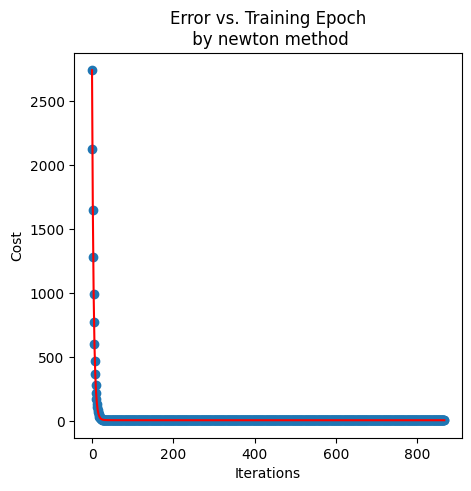

In [ ]:
print('*******************newton*******************')

start = datetime.datetime.now()
st = time.process_time()
g, cost, iter = newton(computeCost, grad, hessian,  theta, iters, tol)
y_pred = x_train.dot(g)
end = datetime.datetime.now()
en = time.process_time()
print("  newton terminated in {} theta = ,  accuracy= {}"
        .format(iter,  accuracy(y_train, y_pred)))

print('Execution time:', end-start)
print('CPU Execution time:', en-st)
#process_memory()
print('cost', len(cost))
print('iter', iter)

draw(iter, cost,'newton')

In [ ]:
print('--------Trainig newton Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)
print('\nMedian Sqaured Error = ',med )

print('\n--------testing newton Model---------------\n')
pred_test = x_test.dot(g)
print("the r2 score is", accuracy(y_test, pred_test))
error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)

--------Trainig newton Model---------------
the r2 score is 0.9393697397219006

residual sum of squares = 15471.785706248607

Mean Sqaured Error =  14.735034005951055

Median Sqaured Error =  5.853302010305136

--------testing newton Model---------------

the r2 score is 0.9156498778144511

residual sum of squares = 7713.459109916487

 mean Squared Srror =  17.14102024425886


*******************gauss_newton*******************
Matrix nearly singular at iteration 0
  gauss_newton terminated in 0 theta = ,  accuracy= -28.05685328378384
Execution time: 0:00:00.009171
CPU Execution time: 0.014788906000006818


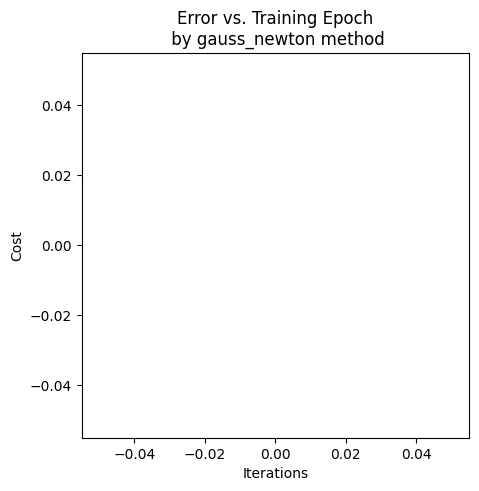

In [ ]:
print('*******************gauss_newton*******************')
#f, g ,h, x0, iterations, error
start = datetime.datetime.now()
st = time.process_time()
g, iter, cost = gauss_newton(x_train, y_train, theta, iters, tol)
thiscost = computeCost(g)
y_pred = x_train.dot(g)

end = datetime.datetime.now()
en = time.process_time()
print("  gauss_newton terminated in {} theta = ,  accuracy= {}"
        .format(iter,  accuracy(y_train, y_pred)))

print('Execution time:', end-start)
print('CPU Execution time:', en-st)
#process_memory()

draw(iter, cost,'gauss_newton')

In [ ]:
print('--------Trainig gauss_newton Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)
print('\nMedian Sqaured Error = ',med )

print('\n--------testing gauss_newton Model---------------\n')
pred_test = x_test.dot(g)
print("the r2 score is", accuracy(y_test, pred_test))
error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)

--------Trainig gauss_newton Model---------------
the r2 score is -inf

residual sum of squares = inf

Mean Sqaured Error =  inf

Median Sqaured Error =  inf

--------testing gauss_newton Model---------------

the r2 score is -inf

residual sum of squares = inf

 mean Squared Srror =  inf


/tmp/ipykernel_240/2190864673.py:2: RuntimeWarning: overflow encountered in power
  r = np.power((Y - f), 2)
/tmp/ipykernel_240/2193548783.py:4: RuntimeWarning: overflow encountered in power
  error = np.power((y_pred -y_train), 2)
/tmp/ipykernel_240/2193548783.py:15: RuntimeWarning: overflow encountered in power
  error = np.power((pred_test -y_test), 2)


In [ ]:
print('\n======= levenberg_marquardt ======\n')
start = datetime.datetime.now()
#st = time.process_time()
theta, n_iter,cost = levenberg_marquardt(x_train, y_train, theta,  iters, tol)
y_pred = x_train.dot(theta)
end = datetime.datetime.now()
#en = time.process_time()

print("  levenberg_marquardt terminated in {} iterations, theta ,  accuracy= {}".format(n_iter+1, accuracy(y_train, y_pred)))

print('Execution time:', end-start)
#print('CPU Execution time:', en-st)
'''
print(len(cost))
print(n_iter+1)
draw(n_iter, cost,'levenberg_marquardt')
'''


======= levenberg_marquardt ======

  levenberg_marquardt terminated in 52 iterations, theta ,  accuracy= -28.056853313319298
Execution time: 0:00:00.162210


"\nprint(len(cost))\nprint(n_iter+1)\ndraw(n_iter, cost,'levenberg_marquardt')\n"

Text(0.5, 1.0, 'Error vs. Training Epoch by  method levenberg_marquardt')

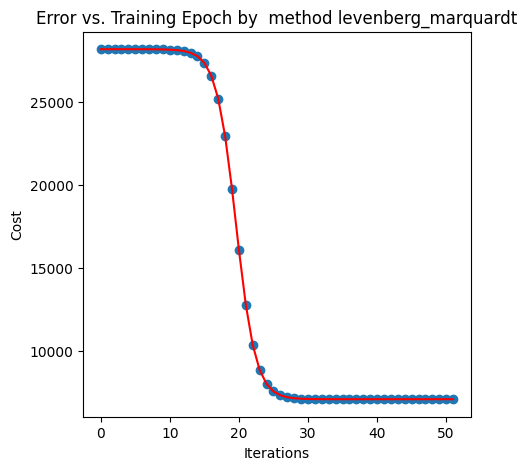

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
plt.scatter(np.arange(n_iter+1), cost, marker='o')
ax.plot(np.arange(n_iter+1), cost, 'r')
ax.set_xlabel('Iterations')
ax.set_ylabel('Cost')
ax.set_title('Error vs. Training Epoch by  method levenberg_marquardt')

In [ ]:
print('--------levenberg_marquardt Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)
print('\nMedian Sqaured Error = ',med )

print('\n--------testing levenberg_marquardt---------------\n')
pred_test = x_test.dot(theta)
print("the r2 score is", accuracy(y_test, pred_test))
error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)

--------levenberg_marquardt Model---------------
the r2 score is -28.056853313319298

residual sum of squares = 7414802.537536934

Mean Sqaured Error =  7061.716702416127

Median Sqaured Error =  7464.9600089271935

--------testing levenberg_marquardt---------------

the r2 score is -34.976589861699814

residual sum of squares = 3289905.7834441448

 mean Squared Srror =  7310.901740986988



======= Broyden-Fletcher-Goldfarb-Shanno ======

  BFGS terminated in 15 iterations, theta,, accuracy= 0.939385338230528
Execution time: 0:00:00.140283
CPU Execution time: 0.2671998970000118


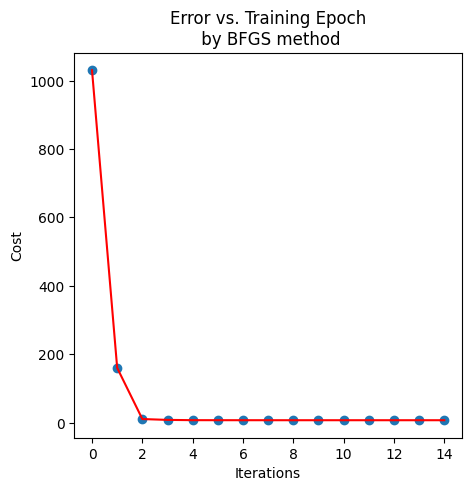

In [ ]:

print('\n======= Broyden-Fletcher-Goldfarb-Shanno ======\n')
start = datetime.datetime.now()
st = time.process_time()

BFGS_theta, BFGS_iter, BFGS_cost = bfgs(computeCost, grad, theta, iters ,  tol)
y_pred = x_train.dot(BFGS_theta)

end = datetime.datetime.now()
en = time.process_time()

print("  BFGS terminated in {} iterations, theta,, accuracy= {}"
      .format(BFGS_iter,  accuracy(y_train, y_pred)))

print('Execution time:', end-start)
print('CPU Execution time:', en-st)

#process_memory()
draw(BFGS_iter, BFGS_cost,'BFGS')

In [ ]:
print('--------Trainig BFGS Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)

print('\nMedian Sqaured Error = ',med )

print('\n--------testing BFGS Model---------------\n')
pred_test = x_test.dot(BFGS_theta)
print("the r2 score is", accuracy(y_test, pred_test))
error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)
#print('\n root mean Squared Srror = ',root_mean_squared_error(y_test, pred_test))

--------Trainig BFGS Model---------------
the r2 score is 0.939385338230528

residual sum of squares = 15467.805238711204

Mean Sqaured Error =  14.731243084486861

Median Sqaured Error =  5.935250553508237

--------testing BFGS Model---------------

the r2 score is 0.9158344550288697

residual sum of squares = 7696.580310465446

 mean Squared Srror =  17.103511801034326


In [ ]:

print('\n======= SR1 ======\n')
start = datetime.datetime.now()
st = time.process_time()

result_theta, iter, cost = SR1(computeCost, grad, theta, iters ,  tol)
y_pred = x_train.dot(result_theta)

end = datetime.datetime.now()
en = time.process_time()

print("  SR1 terminated in {} iterations, theta,, accuracy= {}"
      .format(iter,  accuracy(y_train, y_pred)))

print('Execution time:', end-start)
print('CPU Execution time:', en-st)

#process_memory()
draw(iter, cost,'SR1')


======= SR1 ======



/tmp/ipykernel_317/3647790066.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rho_k = float(1.0 / s_Hy.T.dot(yk))


KeyboardInterrupt: 

In [ ]:
print('--------Trainig SR1 Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)

print('\nMedian Sqaured Error = ',med )

print('\n--------testing SR1 Model---------------\n')
pred_test = x_test.dot(theta)
print("the r2 score is", accuracy(y_test, pred_test))
error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)
#print('\n root mean Squared Srror = ',root_mean_squared_error(y_test, pred_test))

--------Trainig SR1 Model---------------
the r2 score is nan

residual sum of squares = nan

Mean Sqaured Error =  nan

Median Sqaured Error =  nan

--------testing SR1 Model---------------

the r2 score is -0.20721965173570966

residual sum of squares = 3433776.9629411856

 mean Squared Srror =  1093.2113858456496



======= Ml_SR1 ======



/tmp/ipykernel_317/1912122160.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rho_k = float(1.0 / s_Hy.T.dot(yk))


  Ml_SR1 terminated in 999 iterations, theta,, accuracy= -8.685606146179785
Execution time: 0:01:34.308576
CPU Execution time: 93.75001382900001


ValueError: x and y must be the same size

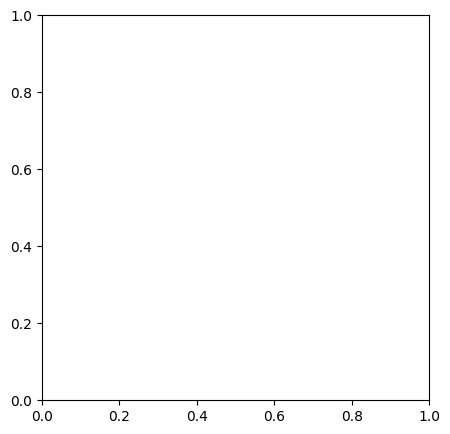

In [ ]:
print('\n======= Ml_SR1 ======\n')
start = datetime.datetime.now()
st = time.process_time()

result_theta, iter, cost = Ml_SR1(computeCost, grad, theta, iters ,  tol)
y_pred = x_train.dot(result_theta)

end = datetime.datetime.now()
en = time.process_time()

print("  Ml_SR1 terminated in {} iterations, theta,, accuracy= {}"
      .format(iter,  accuracy(y_train, y_pred)))

print('Execution time:', end-start)
print('CPU Execution time:', en-st)

#process_memory()
draw(iter, cost,'Ml_SR1')

In [ ]:
print('--------Trainig SR1 Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)

print('\nMedian Sqaured Error = ',med )

print('\n--------testing SR1 Model---------------\n')
pred_test = x_test.dot(result_theta)
print("the r2 score is", accuracy(y_test, pred_test))
error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)
#print('\n root mean Squared Srror = ',root_mean_squared_error(y_test, pred_test))

--------Trainig SR1 Model---------------
the r2 score is 0.8783153835158946

residual sum of squares = 951764.4914984016

Mean Sqaured Error =  129.89825187640258

Median Sqaured Error =  95.3778323166911

--------testing SR1 Model---------------

the r2 score is 0.8635839081697166

residual sum of squares = 388017.5681598709

 mean Squared Srror =  123.53313217442563



======= Memory Less Broyden-Fletcher-Goldfarb-Shanno ======

  Memory_Less BFGS terminated in 20 iterations, theta,  accuracy= 0.9393854216026079
Execution time: 0:00:00.213568


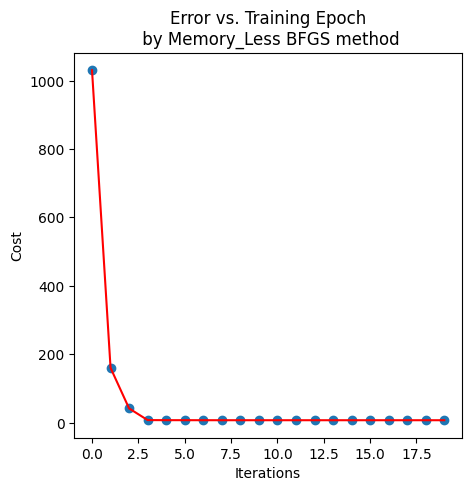

In [ ]:
print('\n======= Memory Less Broyden-Fletcher-Goldfarb-Shanno ======\n')
start = datetime.datetime.now()


MLBFGS_theta, ML_BFGS_iter,ML_BFGS_cost = memory_less_bfgs(computeCost, grad, theta,  iters, tol)

y_pred = x_train.dot(MLBFGS_theta)

end = datetime.datetime.now()


print("  Memory_Less BFGS terminated in {} iterations, theta,  accuracy= {}"
      .format(ML_BFGS_iter, accuracy(y_train, y_pred)))

print('Execution time:', end-start)

#process_memory()
draw(ML_BFGS_iter, ML_BFGS_cost, 'Memory_Less BFGS')

In [ ]:
print('--------Trainig Memory_Less BFGS Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)
print('\nMedian Sqaured Error = ',med )

print('\n--------testing Memory_Less Model---------------\n')
pred_test = x_test.dot(MLBFGS_theta)
print("the r2 score is", accuracy(y_test, pred_test))

error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)


--------Trainig Memory_Less BFGS Model---------------
the r2 score is 0.9393854216026079

residual sum of squares = 15467.783963609538

Mean Sqaured Error =  14.731222822485273

Median Sqaured Error =  5.951132783471751

--------testing Memory_Less Model---------------

the r2 score is 0.9158539144375728

residual sum of squares = 7694.8008304902605

 mean Squared Srror =  17.099557401089466



======= Limited memory Broyden-Fletcher-Goldfarb-Shanno ======

  l-BFGS terminated in 16 iterations, theta ,  accuracy= 0.9393853660421612
Execution time: 0:00:00.134346


/tmp/ipykernel_317/4197534482.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rho_i = float(1.0 / y.T.dot(s))
/tmp/ipykernel_317/4197534482.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a[i] = rho_i * s.T.dot(q)
/tmp/ipykernel_317/4197534482.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rho_i = float(1.0 / y.T.dot(s))
/tmp/ipykernel_317/4197534482.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will 

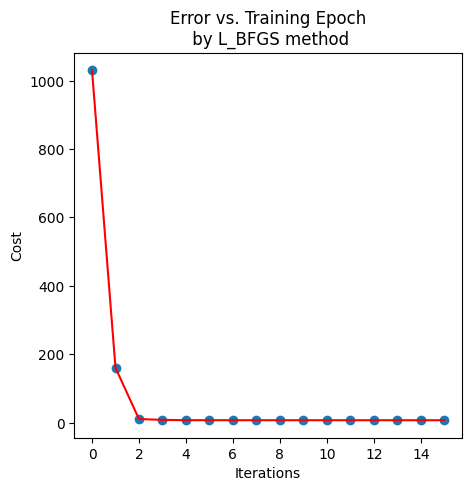

In [ ]:
print('\n======= Limited memory Broyden-Fletcher-Goldfarb-Shanno ======\n')
start = datetime.datetime.now()
st = time.process_time()
LBFGS_theta, l_bfgs_iter,L_BFGS_cost = l_bfgs(computeCost, grad, theta,  iters,tol)
y_pred = x_train.dot(LBFGS_theta)
end = datetime.datetime.now()
en = time.process_time()

print("  l-BFGS terminated in {} iterations, theta ,  accuracy= {}".format(l_bfgs_iter, accuracy(y_train, y_pred)))

print('Execution time:', end-start)
#print('CPU Execution time:', en-st)

draw(l_bfgs_iter, L_BFGS_cost,'L_BFGS')

In [ ]:
print('--------Trainig Limited_Memory BFGS Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)
print('\nMedian Sqaured Error = ',med )

print('\n--------testing Limited_Memory Model---------------\n')
pred_test = x_test.dot(LBFGS_theta)
print("the r2 score is", accuracy(y_test, pred_test))
error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)

--------Trainig Limited_Memory BFGS Model---------------
the r2 score is 0.9393853660421612

residual sum of squares = 15467.798141667174

Mean Sqaured Error =  14.731236325397308

Median Sqaured Error =  5.9507179733088815

--------testing Limited_Memory Model---------------

the r2 score is 0.9158474972322824

residual sum of squares = 7695.387656559086

 mean Squared Srror =  17.10086145902019



======= scaled Broyden-Fletcher-Goldfarb-Shanno ======

  l-scaled_bfgs terminated in 16 iterations, theta ,  accuracy= 0.9393853972718832
Execution time: 0:00:00.133473


/tmp/ipykernel_317/912387528.py:44: RuntimeWarning: divide by zero encountered in scalar divide
  Beta=np.exp(-1/np.power(i,2))
/tmp/ipykernel_317/912387528.py:49: RuntimeWarning: divide by zero encountered in scalar divide
  if alpha <np.exp(-1/np.power(i,2)):


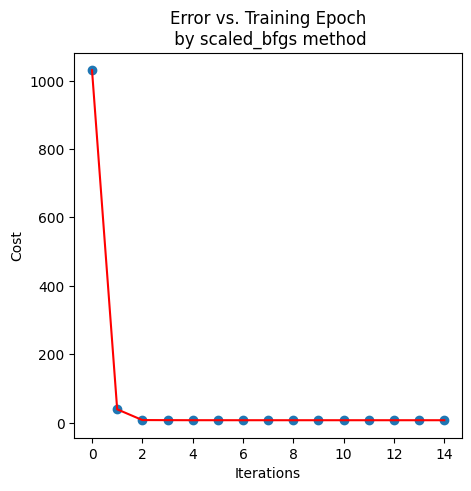

In [ ]:

print('\n======= scaled Broyden-Fletcher-Goldfarb-Shanno ======\n')
start = datetime.datetime.now()
#st = time.process_time()
scaled_bfgs_theta, n_iter,scaled_cost = scaled_bfgs(computeCost, grad, theta,  iters, tol)
y_pred = x_train.dot(scaled_bfgs_theta)
end = datetime.datetime.now()
#en = time.process_time()

print("  l-scaled_bfgs terminated in {} iterations, theta ,  accuracy= {}".format(n_iter+1, accuracy(y_train, y_pred)))

print('Execution time:', end-start)
#print('CPU Execution time:', en-st)

draw(n_iter, scaled_cost,'scaled_bfgs')

In [ ]:
print('--------Trainig scaled BFGS Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)
print('\nMedian Sqaured Error = ',med )

print('\n--------testing scaled BFGS Model---------------\n')
pred_test = x_test.dot(scaled_bfgs_theta)
print("the r2 score is", accuracy(y_test, pred_test))
error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)

--------Trainig scaled BFGS Model---------------
the r2 score is 0.9393853972718832

residual sum of squares = 15467.790172386405

Mean Sqaured Error =  14.7312287356061

Median Sqaured Error =  5.934714745867538

--------testing scaled BFGS Model---------------

the r2 score is 0.91584909674721

residual sum of squares = 7695.241387737295

 mean Squared Srror =  17.10053641719399



======= double scaled Broyden-Fletcher-Goldfarb-Shanno ======

  l-scaled_bfgs terminated in 12 iterations, theta ,  accuracy= 0.9392693098674586
Execution time: 0:00:00.161190


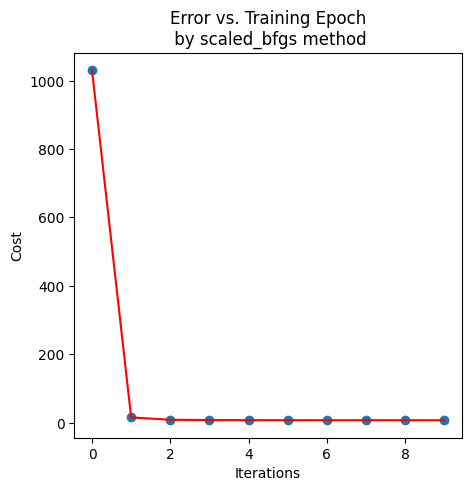

In [ ]:
print('\n======= double scaled Broyden-Fletcher-Goldfarb-Shanno ======\n')
start = datetime.datetime.now()
#st = time.process_time()
scaled_bfgs_theta, n_iter,scaled_cost = double_scaled_bfgs(computeCost, grad, theta,  iters, tol)
y_pred = x_train.dot(scaled_bfgs_theta)
end = datetime.datetime.now()
#en = time.process_time()

print("  l-scaled_bfgs terminated in {} iterations, theta ,  accuracy= {}".format(n_iter+1, accuracy(y_train, y_pred)))

print('Execution time:', end-start)
#print('CPU Execution time:', en-st)

draw(n_iter-1, scaled_cost,'scaled_bfgs')

In [ ]:
print('--------Trainig double scaled BFGS Model---------------')
print("the r2 score is", accuracy(y_train, y_pred))

error = np.power((y_pred -y_train), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\nMean Sqaured Error = ',mse )
med = np.median(error)
print('\nMedian Sqaured Error = ',med )

print('\n--------testing double scaled BFGS Model---------------\n')
pred_test = x_test.dot(scaled_bfgs_theta)
print("the r2 score is", accuracy(y_test, pred_test))
error = np.power((pred_test -y_test), 2)
rss = np.sum(error)
print('\nresidual sum of squares =',rss )
mse = np.mean(error)
print('\n mean Squared Srror = ', mse)

--------Trainig double scaled BFGS Model---------------
the r2 score is 0.9392693098674586

residual sum of squares = 15497.41365472367

Mean Sqaured Error =  14.759441575927305

Median Sqaured Error =  5.8761032391256

--------testing double scaled BFGS Model---------------

the r2 score is 0.9154185282894419

residual sum of squares = 7734.615037792106

 mean Squared Srror =  17.18803341731579


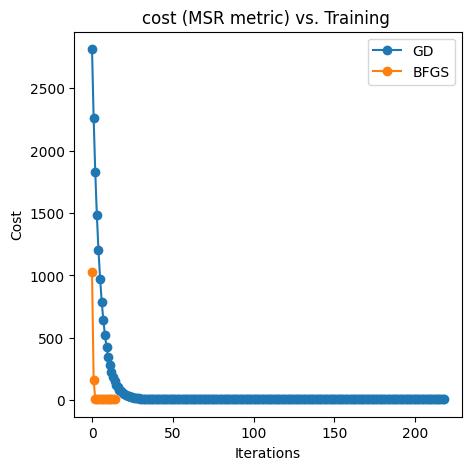

In [ ]:
# draw error graph
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(np.arange(GD_iter), GD_cost, marker = 'o')
ax.plot(np.arange(BFGS_iter), BFGS_cost, marker = 'o')
#ax.plot(np.arange(ML_BFGS_iter+1), ML_BFGS_cost, marker = 'o')
#ax.plot(np.arange(l_bfgs_iter+1), L_BFGS_cost, marker = 'o')

#ax.plot(np.arange(n_iter+1), scaled_cost, marker = 'o')

ax.set_xlabel('Iterations')
ax.set_ylabel('Cost')
ax.set_title('cost (MSR metric) vs. Training ')
ax.legend(['GD','BFGS','ML_BFGS','L_BFG','scaled_BFGS'])
plt.show()

# apply different regressors

In [ ]:
# ==========================
# Import required libraries
# ==========================
import datetime
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge, LinearRegression
from sklearn.svm import SVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor

In [ ]:

# ========================================
# Prepare PCA-based regression (PCR setup)
# ========================================
# PCR = PCA + Linear Regression pipeline
pcr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),      # you can tune n_components as needed
    ('regressor', LinearRegression())
])

# ==============================
# Initialize regression models
# ==============================
models = {
    "Ridge Regression": Ridge(alpha=1),
    "Lasso Regression": Lasso(alpha=1),
    "ElasticNet Regression": ElasticNet(),
    "Principal Component Regression (PCR)": pcr_model,
    "Partial Least Squares (PLS) Regression": PLSRegression(n_components=5),  # tune components as needed
    "Support Vector Regression (SVR)": SVR(kernel='rbf'),
    "Bayesian Linear Regression": BayesianRidge()
}

# ==============================
# Print model names to verify
# ==============================
print("Models to be trained:\n", list(models.keys()))
print("="*70)

# ========================================
# Train, predict, and evaluate each model
# ========================================
for name, model in models.items():
    print('*' * 10, name, '*' * 10)

    start = datetime.datetime.now()
    model.fit(X_train, y_train)
    end = datetime.datetime.now()

    # Predict results
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate performance
    mse = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"Mean Squared Error: {mse:.6f}")
    print(f"Training R²: {r2_train:.6f}, Test R²: {r2_test:.6f}")
    print('Execution time:', end - start)
    print('\n')


Models to be trained:
 ['Ridge Regression', 'Lasso Regression', 'ElasticNet Regression', 'Principal Component Regression (PCR)', 'Partial Least Squares (PLS) Regression', 'Support Vector Regression (SVR)', 'Bayesian Linear Regression']
********** Ridge Regression **********
Mean Squared Error: 17.098309
Training R²: 0.939385, Test R²: 0.915860
Execution time: 0:00:00.013255


********** Lasso Regression **********
Mean Squared Error: 16.320950
Training R²: 0.922910, Test R²: 0.919685
Execution time: 0:00:00.012734


********** ElasticNet Regression **********
Mean Squared Error: 21.254779
Training R²: 0.900690, Test R²: 0.895406
Execution time: 0:00:00.011331


********** Principal Component Regression (PCR) **********
Mean Squared Error: 33.522684
Training R²: 0.859007, Test R²: 0.835037
Execution time: 0:00:00.063362


********** Partial Least Squares (PLS) Regression **********
Mean Squared Error: 17.309873
Training R²: 0.938858, Test R²: 0.914819
Execution time: 0:00:00.016207


**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Squared Error: 122.310474
Training R²: 0.467378, Test R²: 0.398116
Execution time: 0:00:00.146943


********** Bayesian Linear Regression **********
Mean Squared Error: 17.086057
Training R²: 0.939051, Test R²: 0.915920
Execution time: 0:00:00.036901




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# Initialize different regression models
models = {

    "Linear Regression": LinearRegression(),
    #"Ridge Regression": Ridge(),
    #"Lasso Regression": Lasso(),
    #"ElasticNet Regression": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "Support Vector Regressor (SVR)": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Gaussian Process": GaussianProcessRegressor(),
    "Neural Network (MLP)": MLPRegressor()


}
# Print model names to verify
print(models.keys())


dict_keys(['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'AdaBoost', 'Support Vector Regressor (SVR)', 'K-Nearest Neighbors', 'Gaussian Process', 'Neural Network (MLP)'])


In [ ]:
# Print model names to# Train and evaluate models
for name, model in models.items():
    print('*'*10,name,'*'*10)
    start = datetime.datetime.now()
    model.fit(X_train, y_train)
    end = datetime.datetime.now()
    #print(X_train.shape)
    y_train_pred = model.predict(X_train)

    #predict result
    y_test_pred = model.predict(X_test)

    mse = mean_squared_error( y_test, y_test_pred)
    print(f"Mean Squared Error: {mse}")


    #compute accuracy
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    print(f'training r2: {r2_train}, test r2: {r2_test}')
    print('Execution time:', end-start)
    print('\n')


********** Linear Regression **********
Mean Squared Error: 17.100953930693798
training r2: 0.9393854417267521, test r2: 0.9158470421836997
Execution time: 0:00:00.020956


********** Decision Tree **********
Mean Squared Error: 37.82251111111111
training r2: 1.0, test r2: 0.813877272873821
Execution time: 0:00:00.051215


********** Random Forest **********


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Squared Error: 15.551779046666658
training r2: 0.9902759647417164, test r2: 0.9234704560116042
Execution time: 0:00:01.828862


********** Gradient Boosting **********


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Mean Squared Error: 14.884876306022747
training r2: 0.9659089206768393, test r2: 0.9267522517774095
Execution time: 0:00:00.704687


********** AdaBoost **********


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Squared Error: 122.31047392405416
training r2: 0.46737797575306295, test r2: 0.39811614051842337
Execution time: 0:00:00.167808


********** K-Nearest Neighbors **********
Mean Squared Error: 176.28152088888888
training r2: 0.444543582383065, test r2: 0.13252725834610402
Execution time: 0:00:00.004329


********** Gaussian Process **********
Mean Squared Error: 7310.901699922707
training r2: 1.0, test r2: -34.976589659624494
Execution time: 0:00:00.716154


********** Neural Network (MLP) **********


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Squared Error: 75.81162885419526
training r2: 0.9662042767979359, test r2: 0.6269346826611051
Execution time: 0:00:01.956185




/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Initialize different regression models
models = {
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}
# Print model names to verify
print(models.keys())


dict_keys(['Decision Tree', 'Random Forest', 'Gradient Boosting'])


In [ ]:
# Print model names to# Train and evaluate models
for name, model in models.items():
    print('*'*10,name,'*'*10)
    start = datetime.datetime.now()
    model.fit(X_train, y_train)
    end = datetime.datetime.now()
    #print(X_train.shape)
    y_train_pred = model.predict(X_train)

    #predict result
    y_test_pred = model.predict(X_test)

    mse = mean_squared_error( y_test, y_test_pred)
    print(f"Mean Squared Error: {mse}")


    #compute accuracy
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    print(f'training r2: {r2_train}, test r2: {r2_test}')
    print('Execution time:', end-start)
    print('\n')


********** Decision Tree **********
Mean Squared Error: 0.05115555555555557
training r2: 1.0, test r2: 0.9997482660133357
Execution time: 0:00:00.017433


********** Random Forest **********


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Squared Error: 0.007993162222221665
training r2: 0.999991038655227, test r2: 0.9999606660396823
Execution time: 0:00:00.998873


********** Gradient Boosting **********


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Mean Squared Error: 0.01749311698988918
training r2: 0.999975589977067, test r2: 0.9999139172269517
Execution time: 0:00:00.420491




In [ ]:
# Print model names to# Train and evaluate models
for name, model in models.items():
    print('*'*10,name,'*'*10)
    start = datetime.datetime.now()
    model.fit(X_train, y_train)
    end = datetime.datetime.now()
    #print(X_train.shape)
    y_train_pred = model.predict(X_train)

    #predict result
    y_test_pred = model.predict(X_test)

    mse = mean_squared_error( y_test, y_test_pred)
    print(f"Mean Squared Error: {mse}")


    #compute accuracy
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    print(f'training r2: {r2_train}, test r2: {r2_test}')
    print('Execution time:', end-start)
    print('\n')


********** Decision Tree **********
Mean Squared Error: 0.049133333333333404
training r2: 1.0, test r2: 0.9997582172699762
Execution time: 0:00:00.016069


********** Gradient Boosting **********


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Mean Squared Error: 0.01753552993394985
training r2: 0.999975589977067, test r2: 0.9999137085149286
Execution time: 0:00:00.416981


********** AdaBoost **********
Mean Squared Error: 1.2102348756445493
training r2: 0.9951879506937722, test r2: 0.9940444933744231
Execution time: 0:00:00.045728


********** Support Vector Regressor (SVR) **********


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Squared Error: 44.277099081195175
training r2: 0.8120848731662385, test r2: 0.7821145611929734
Execution time: 0:00:00.083045


********** K-Nearest Neighbors **********
Mean Squared Error: 69.56663822222222
training r2: 0.772323830181791, test r2: 0.6576659760933595
Execution time: 0:00:00.001609


********** Gaussian Process **********
Mean Squared Error: 7310.901339936638
training r2: 1.0, test r2: -34.976587888150654
Execution time: 0:00:00.170703


********** Neural Network (MLP) **********


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Squared Error: 70.47284812589376
training r2: 0.9075881501033853, test r2: 0.6532065614837741
Execution time: 0:00:01.331302




/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
